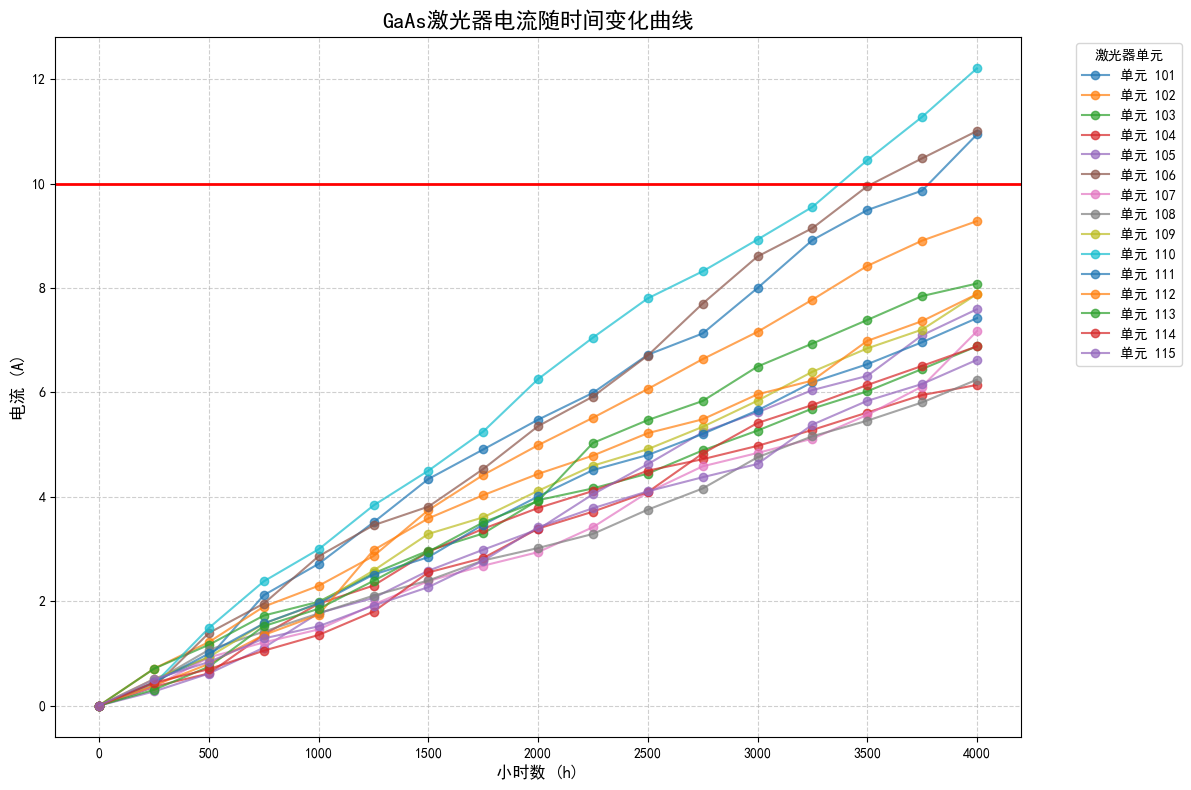

绘图完成。


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置matplotlib以支持中文显示 (根据您的系统环境可能需要调整字体)
# Windows系统通常使用 'SimHei', Mac系统可能使用 'Arial Unicode MS' 或 'Heiti TC'
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取Excel文件
# 假设文件名为 'project1附件-GaAs激光器退化数据.xlsx'
# 注意：实际运行时请确保文件路径正确
file_path = r'data\课题一\project1附件-GaAs激光器退化数据.xlsx'

try:
    # 读取数据，跳过前两行表头（根据文件结构，实际数据从第3行开始，列名为：编号, 电流, 单元, 小时数, 批次）
    # 如果文件结构不同，可能需要调整 skiprows 参数
    df = pd.read_excel(file_path, skiprows=2)
    
    # 重命名列以便处理 (根据检索到的内容列名可能是空的或者需要标准化)
    # 检索结果显示列名为：编号, 电流, 单元, 小时数, 批次
    # 如果读入的列名是数字索引，手动指定
    if isinstance(df.columns[0], int):
        df.columns = ['编号', '电流', '单元', '小时数', '批次']

    # 2. 数据预处理
    # 确保'小时数'和'电流'是数值类型
    df['小时数'] = pd.to_numeric(df['小时数'], errors='coerce')
    df['电流'] = pd.to_numeric(df['电流'], errors='coerce')
    df['单元'] = df['单元'].astype(str) # 将单元作为分类变量处理

    # 3. 绘制曲线
    plt.figure(figsize=(12, 8))

    # 按'单元'分组绘图
    grouped = df.groupby('单元')
    
    for name, group in grouped:
        # 按小时数排序，确保连线顺序正确
        group = group.sort_values('小时数')
        plt.plot(group['小时数'], group['电流'], marker='o', label=f'单元 {name}', alpha=0.7)

    plt.title('GaAs激光器电流随时间变化曲线', fontsize=16)
    plt.xlabel('小时数 (h)', fontsize=12)
    plt.ylabel('电流 (A)', fontsize=12)
    plt.axhline(y=10, color='red', linewidth=2)
    plt.legend(title='激光器单元', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # 显示图表
    plt.show()

    print("绘图完成。")

except FileNotFoundError:
    print(f"错误：找不到文件 {file_path}，请检查文件路径。")
except Exception as e:
    print(f"发生错误：{e}")